# VALOR Live Demo — From Transcript to Coaching Insights

**Scenario:** You just finished a sales call that didn't go well. You have the transcript and want to understand *why* it failed by comparing your KAAPAV phase distribution against successful and unsuccessful call benchmarks.

**Pipeline:**
1. Train the fine-tuned `bert-base-german-cased` classifier (~60s on GPU)
2. Classify each segment of your transcript by KAAPAV phase
3. Apply Viterbi smoothing to enforce phase ordering
4. Compare your phase distribution to benchmarks (successful vs unsuccessful calls)
5. Get actionable coaching insights

**Runtime:** set *Runtime → Change runtime type → GPU*.

## 0. Setup & Data

In [1]:
!pip install -q transformers datasets evaluate accelerate scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00


In [2]:
import os, pathlib, json, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download training data directly from GitHub
REPO_RAW = 'https://raw.githubusercontent.com/bobbypakenham/NLP-Project/main'
DATA_DIR = pathlib.Path('data')
DATA_DIR.mkdir(exist_ok=True)

for fn in ['synthetic_transcripts.jsonl', 'gold_eval.jsonl']:
    dest = DATA_DIR / fn
    if not dest.exists():
        print(f'Downloading {fn}...')
        urllib.request.urlretrieve(f'{REPO_RAW}/{fn}', dest)

ROOT = pathlib.Path('.')
print('Data ready:', list(DATA_DIR.glob('*.jsonl')))

Data ready: [PosixPath('data/synthetic_transcripts.jsonl'), PosixPath('data/gold_eval.jsonl')]


## 1. Train the KAAPAV classifier

We fine-tune `bert-base-german-cased` on 1,231 labelled segments from 32 calls. This takes ~60 seconds on a Colab GPU. The model achieves 0.73 accuracy on its own, and 0.82 with Viterbi smoothing.

In [3]:
def load_jsonl(p):
    return [json.loads(l) for l in open(p, encoding='utf-8') if l.strip()]

train_segs = load_jsonl(DATA_DIR/'synthetic_transcripts.jsonl')
PHASES = ['Kontakt','Analyse','Angebot','Pruefung','Abschluss','Verstaerkung']
PHASE_EN = {
    'Kontakt': 'Contact', 'Analyse': 'Analysis', 'Angebot': 'Offer',
    'Pruefung': 'Review', 'Abschluss': 'Closing', 'Verstaerkung': 'Reinforcement'
}
PHASE_LABELS = [f"{p} ({PHASE_EN[p]})" for p in PHASES]
lab2id = {p:i for i,p in enumerate(PHASES)}
id2lab = {i:p for p,i in lab2id.items()}
N = len(PHASES)

# Add relative position
by_call = {}
for s in train_segs: by_call.setdefault(s['call_id'],[]).append(s)
for cs in by_call.values():
    cs.sort(key=lambda s:s['turn']); n=len(cs)
    for i,s in enumerate(cs): s['rel_position'] = i/(n-1) if n>1 else 0.0

# Build dataframe with position tags
rows = []
for s in train_segs:
    bucket = ['START','EARLY','MID','LATE','END'][min(4,int(s['rel_position']*5))]
    rows.append({'text': f"[{s['speaker'].upper()}|{bucket}] {s['text']}",
                 'label': lab2id[s['phase']], 'call_id': s['call_id'],
                 'turn': s['turn'], 'phase': s['phase']})
train_df = pd.DataFrame(rows)

# Split into train/validation by call_id
from sklearn.model_selection import GroupShuffleSplit
from datasets import Dataset, DatasetDict

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, val_idx = next(gss.split(train_df, groups=train_df['call_id']))
ds = DatasetDict({
    'train': Dataset.from_pandas(train_df.iloc[tr_idx].reset_index(drop=True)),
    'validation': Dataset.from_pandas(train_df.iloc[val_idx].reset_index(drop=True))
})
print(f'Training: {len(ds["train"])} segments | Validation: {len(ds["validation"])} segments')

Training: 1036 segments | Validation: 195 segments


In [4]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding, set_seed)
import evaluate

checkpoint = 'bert-base-german-cased'
tok = AutoTokenizer.from_pretrained(checkpoint)
collator = DataCollatorWithPadding(tokenizer=tok)

def prep(b): return tok(b['text'], truncation=True)
tds = ds.map(prep, batched=True)

set_seed(42)
acc_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(p):
    logits, labels = p
    pred = np.argmax(logits, axis=-1)
    return {'accuracy': acc_metric.compute(predictions=pred, references=labels)['accuracy'],
            'macro_f1': f1_metric.compute(predictions=pred, references=labels, average='macro')['f1']}

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=N, id2label=id2lab, label2id=lab2id)

args = TrainingArguments(
    output_dir='./kaapav_gbert', learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    num_train_epochs=4, weight_decay=0.01, eval_strategy='epoch',
    save_strategy='epoch', load_best_model_at_end=True,
    metric_for_best_model='macro_f1', logging_steps=25, seed=42)

trainer = Trainer(model=model, args=args, train_dataset=tds['train'],
    eval_dataset=tds['validation'], data_collator=collator,
    compute_metrics=compute_metrics)

trainer.train()
print('\nTraining complete!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/485k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!


## 2. Learn Viterbi transition priors

We estimate the transition matrix from the training calls. This captures the natural forward-flow of KAAPAV phases (no backward jumps in real calls).

In [5]:
import scipy.special as sp

IDX = {p:i for i,p in enumerate(PHASES)}

def learn_priors(df, alpha=1.0):
    T = np.full((N,N), alpha)
    st = np.full(N, alpha)
    for _, grp in df.groupby('call_id'):
        seq = [IDX[p] for p in grp.sort_values('turn')['phase']]
        st[seq[0]] += 1
        for a, b in zip(seq, seq[1:]): T[a,b] += 1
    T /= T.sum(1, keepdims=True)
    st /= st.sum()
    return np.log(T), np.log(st)

T_LOG, ST_LOG = learn_priors(train_df)

def viterbi(emission_logprobs):
    n = emission_logprobs.shape[0]
    dp = np.full((n, N), -np.inf)
    backtrack = np.zeros((n, N), dtype=int)
    dp[0] = ST_LOG + emission_logprobs[0]
    for t in range(1, n):
        scores = dp[t-1][:, None] + T_LOG
        backtrack[t] = scores.argmax(0)
        dp[t] = scores.max(0) + emission_logprobs[t]
    path = [int(dp[-1].argmax())]
    for t in range(n-1, 0, -1):
        path.append(int(backtrack[t, path[-1]]))
    return list(reversed(path))

print('Transition priors learned from training data.')

Transition priors learned from training data.


---
## 3. Your transcript

Here is the call you want to analyse. Paste any transcript here as a list of speaker/text pairs and the notebook will classify it.

In [6]:
transcript = [
    {"speaker": "Berater", "text": "Guten Tag, mein Name ist Müller von der Sparkasse. Wie kann ich Ihnen heute helfen?"},
    {"speaker": "Kunde", "text": "Hallo Herr Müller, danke für den Rückruf. Ich hatte letzte Woche angerufen."},
    {"speaker": "Berater", "text": "Ja genau, ich sehe das hier. Sie hatten sich wegen einer Geldanlage gemeldet, richtig?"},
    {"speaker": "Kunde", "text": "Genau, ich habe etwas Geld geerbt und möchte es sinnvoll anlegen. Ich bin da etwas unsicher."},
    {"speaker": "Berater", "text": "Verstehe. Darf ich fragen, wie viel es ungefähr ist?"},
    {"speaker": "Kunde", "text": "Es sind etwa fünfzigtausend Euro. Ich habe das momentan einfach auf dem Girokonto liegen."},
    {"speaker": "Berater", "text": "Okay, dann würde ich Ihnen unseren Sparkassen-Fonds empfehlen. Der hat eine gute Rendite und ist breit gestreut."},
    {"speaker": "Kunde", "text": "Hmm, was genau ist denn die Rendite? Und wie sicher ist das?"},
    {"speaker": "Berater", "text": "Die Rendite lag letztes Jahr bei etwa vier Prozent. Es ist ein gemischter Fonds mit Aktien und Anleihen."},
    {"speaker": "Kunde", "text": "Vier Prozent klingt nicht schlecht. Aber ich habe eigentlich noch nie in Fonds investiert."},
    {"speaker": "Berater", "text": "Das ist kein Problem, viele unserer Kunden starten so. Der Fonds ist gut gemanagt."},
    {"speaker": "Kunde", "text": "Aber was passiert, wenn der Markt einbricht? Kann ich mein Geld dann verlieren?"},
    {"speaker": "Berater", "text": "Naja, ein gewisses Risiko gibt es immer. Aber langfristig ist die Rendite positiv."},
    {"speaker": "Kunde", "text": "Ich bin mir nicht sicher, ob Fonds das Richtige für mich sind. Gibt es denn keine sichereren Optionen?"},
    {"speaker": "Berater", "text": "Es gibt natürlich Tagesgeld, aber da bekommen Sie kaum Zinsen. Der Fonds ist wirklich die bessere Wahl."},
    {"speaker": "Kunde", "text": "Hmm, ich weiß nicht. Das klingt alles etwas riskant für mich."},
    {"speaker": "Berater", "text": "Also ich würde sagen, wir machen das einfach. Sollen wir einen Termin zur Unterschrift ausmachen?"},
    {"speaker": "Kunde", "text": "Nein, das geht mir zu schnell. Ich muss erst mal in Ruhe darüber nachdenken."},
    {"speaker": "Berater", "text": "Natürlich, kein Problem. Nehmen Sie sich die Zeit die Sie brauchen."},
    {"speaker": "Kunde", "text": "Ja, ich melde mich dann wieder. Vielleicht bespreche ich das auch nochmal mit meiner Frau."},
    {"speaker": "Berater", "text": "Das ist eine gute Idee. Sie können mich jederzeit wieder anrufen."},
    {"speaker": "Kunde", "text": "Danke, Herr Müller. Auf Wiederhören."},
    {"speaker": "Berater", "text": "Auf Wiederhören, einen schönen Tag noch."},
]

print(f'{len(transcript)} segments loaded')
for seg in transcript:
    print(f"  {seg['speaker']}: {seg['text'][:80]}..." if len(seg['text'])>80 else f"  {seg['speaker']}: {seg['text']}")

23 segments loaded
  Berater: Guten Tag, mein Name ist Müller von der Sparkasse. Wie kann ich Ihnen heute helf...
  Kunde: Hallo Herr Müller, danke für den Rückruf. Ich hatte letzte Woche angerufen.
  Berater: Ja genau, ich sehe das hier. Sie hatten sich wegen einer Geldanlage gemeldet, ri...
  Kunde: Genau, ich habe etwas Geld geerbt und möchte es sinnvoll anlegen. Ich bin da etw...
  Berater: Verstehe. Darf ich fragen, wie viel es ungefähr ist?
  Kunde: Es sind etwa fünfzigtausend Euro. Ich habe das momentan einfach auf dem Girokont...
  Berater: Okay, dann würde ich Ihnen unseren Sparkassen-Fonds empfehlen. Der hat eine gute...
  Kunde: Hmm, was genau ist denn die Rendite? Und wie sicher ist das?
  Berater: Die Rendite lag letztes Jahr bei etwa vier Prozent. Es ist ein gemischter Fonds ...
  Kunde: Vier Prozent klingt nicht schlecht. Aber ich habe eigentlich noch nie in Fonds i...
  Berater: Das ist kein Problem, viele unserer Kunden starten so. Der Fonds ist gut gemanag...
  Kunde:

## 4. Feature engineering — add position tags

We prepend `[SPEAKER|POSITION_BUCKET]` tags to each segment, exactly as done during training. This helps the model disambiguate identical phrases that appear in different phases depending on their position in the call.

In [7]:
def tag_segments(transcript):
    n = len(transcript)
    tagged = []
    for i, seg in enumerate(transcript):
        rel_pos = i / (n - 1) if n > 1 else 0.0
        bucket = ['START','EARLY','MID','LATE','END'][min(4, int(rel_pos * 5))]
        speaker = 'ADVISOR' if seg['speaker'] == 'Berater' else 'CLIENT'
        tagged.append(f"[{speaker}|{bucket}] {seg['text']}")
    return tagged

tagged_texts = tag_segments(transcript)
print('Tagged segments:')
for t in tagged_texts[:4]:
    print(f'  {t}')
print('  ...')

Tagged segments:
  [ADVISOR|START] Guten Tag, mein Name ist Müller von der Sparkasse. Wie kann ich Ihnen heute helfen?
  [CLIENT|START] Hallo Herr Müller, danke für den Rückruf. Ich hatte letzte Woche angerufen.
  [ADVISOR|START] Ja genau, ich sehe das hier. Sie hatten sich wegen einer Geldanlage gemeldet, richtig?
  [CLIENT|START] Genau, ich habe etwas Geld geerbt und möchte es sinnvoll anlegen. Ich bin da etwas unsicher.
  ...


## 5. Classify with BERT + Viterbi

First we get per-segment probabilities from the fine-tuned BERT, then apply Viterbi decoding to enforce the natural KAAPAV phase ordering.

In [8]:
import torch

# Get BERT logits
inputs = tok(tagged_texts, padding=True, truncation=True, return_tensors='pt')
model.eval()
with torch.no_grad():
    logits = model(**inputs.to(model.device)).logits.cpu().numpy()

bert_preds = np.argmax(logits, axis=-1)
print('BERT raw predictions:       ', [f"{PHASES[p]} ({PHASE_EN[PHASES[p]]})" for p in bert_preds])

# Apply Viterbi smoothing
probs = sp.softmax(logits, axis=1)
emission_log = np.log(np.clip(probs, 1e-12, 1))
viterbi_preds = viterbi(emission_log)
print('Viterbi-smoothed predictions:', [f"{PHASES[p]} ({PHASE_EN[PHASES[p]]})" for p in viterbi_preds])

BERT raw predictions:        ['Analyse (Analysis)', 'Kontakt (Contact)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Angebot (Offer)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Angebot (Offer)', 'Pruefung (Review)', 'Angebot (Offer)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Verstaerkung (Reinforcement)', 'Pruefung (Review)', 'Verstaerkung (Reinforcement)', 'Verstaerkung (Reinforcement)', 'Verstaerkung (Reinforcement)']
Viterbi-smoothed predictions: ['Kontakt (Contact)', 'Kontakt (Contact)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Analyse (Analysis)', 'Angebot (Offer)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Pruefung (Review)', 'Verstaerkung (Reinforceme

## 6. Classified transcript

Your transcript with each segment labelled by KAAPAV phase:

In [9]:
results_df = pd.DataFrame({
    'Speaker': [s['speaker'] for s in transcript],
    'Text': [s['text'] for s in transcript],
    'Phase': [PHASES[p] for p in viterbi_preds],
    'Phase (EN)': [PHASE_EN[PHASES[p]] for p in viterbi_preds]
})

phase_colors = {
    'Kontakt': '\033[94m', 'Analyse': '\033[92m', 'Angebot': '\033[93m',
    'Pruefung': '\033[95m', 'Abschluss': '\033[91m', 'Verstaerkung': '\033[96m'
}
RESET = '\033[0m'

print()
for _, row in results_df.iterrows():
    color = phase_colors[row['Phase']]
    label = f"{row['Phase']} ({row['Phase (EN)']})"
    print(f"{color}[{label:>25}]{RESET}  {row['Speaker']}: {row['Text']}")
print(f'\n--- {len(results_df)} segments classified ---')


[        Kontakt (Contact)]  Berater: Guten Tag, mein Name ist Müller von der Sparkasse. Wie kann ich Ihnen heute helfen?
[        Kontakt (Contact)]  Kunde: Hallo Herr Müller, danke für den Rückruf. Ich hatte letzte Woche angerufen.
[       Analyse (Analysis)]  Berater: Ja genau, ich sehe das hier. Sie hatten sich wegen einer Geldanlage gemeldet, richtig?
[       Analyse (Analysis)]  Kunde: Genau, ich habe etwas Geld geerbt und möchte es sinnvoll anlegen. Ich bin da etwas unsicher.
[       Analyse (Analysis)]  Berater: Verstehe. Darf ich fragen, wie viel es ungefähr ist?
[       Analyse (Analysis)]  Kunde: Es sind etwa fünfzigtausend Euro. Ich habe das momentan einfach auf dem Girokonto liegen.
[       Analyse (Analysis)]  Berater: Okay, dann würde ich Ihnen unseren Sparkassen-Fonds empfehlen. Der hat eine gute Rendite und ist breit gestreut.
[       Analyse (Analysis)]  Kunde: Hmm, was genau ist denn die Rendite? Und wie sicher ist das?
[       Analyse (Analysis)]  Berater: Die Rend

## 7. Compare against benchmarks

We compare the phase time allocation of your call against two benchmarks derived from the training data:
- **Successful calls** (ended in a sale): longer Analyse and Angebot phases, thorough needs discovery
- **Unsuccessful calls** (no sale): rushed Analyse, weak Pruefung handling

In [10]:
# Benchmark distributions (% of segments per phase)
# K=Contact, A=Analysis, A=Offer, P=Review, A=Closing, V=Reinforcement
benchmarks = {
    'Successful calls': np.array([0.08, 0.32, 0.27, 0.15, 0.12, 0.06]),
    'Unsuccessful calls': np.array([0.14, 0.14, 0.17, 0.30, 0.16, 0.09]),
}

# Your call's distribution
my_counts = np.array([viterbi_preds.count(i) for i in range(N)])
my_dist = my_counts / my_counts.sum()

print('Your call — phase distribution:')
for label, pct in zip(PHASE_LABELS, my_dist):
    print(f'  {label:>30}: {pct:.0%}')

Your call — phase distribution:
               Kontakt (Contact): 9%
              Analyse (Analysis): 35%
                 Angebot (Offer): 4%
               Pruefung (Review): 30%
             Abschluss (Closing): 0%
    Verstaerkung (Reinforcement): 22%


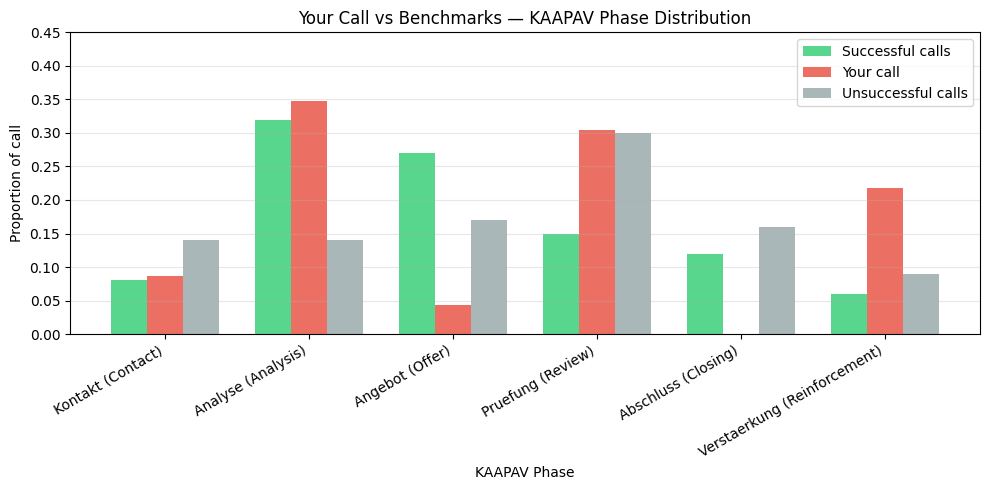

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(N)
width = 0.25

ax.bar(x - width, benchmarks['Successful calls'], width, label='Successful calls', color='#2ecc71', alpha=0.8)
ax.bar(x, my_dist, width, label='Your call', color='#e74c3c', alpha=0.8)
ax.bar(x + width, benchmarks['Unsuccessful calls'], width, label='Unsuccessful calls', color='#95a5a6', alpha=0.8)

ax.set_xlabel('KAAPAV Phase')
ax.set_ylabel('Proportion of call')
ax.set_title('Your Call vs Benchmarks — KAAPAV Phase Distribution')
ax.set_xticks(x)
ax.set_xticklabels(PHASE_LABELS, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 0.45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Coaching insights

Based on the comparison against successful calls, here is your actionable feedback:

In [12]:
print('=' * 60)
print('COACHING INSIGHTS')
print('=' * 60)

success_dist = benchmarks['Successful calls']
diff = my_dist - success_dist

insights = []
for i, phase in enumerate(PHASES):
    label = PHASE_LABELS[i]
    delta = diff[i]
    if delta < -0.08:
        insights.append(f'  - {label}: You spent significantly LESS time here than successful calls '
                       f'({my_dist[i]:.0%} vs {success_dist[i]:.0%}). '
                       f'Consider spending more time in this phase.')
    elif delta > 0.08:
        insights.append(f'  - {label}: You spent significantly MORE time here than successful calls '
                       f'({my_dist[i]:.0%} vs {success_dist[i]:.0%}). '
                       f'This phase may be dragging the call.')

if insights:
    print('\nKey differences from successful calls:\n')
    for ins in insights:
        print(ins)
else:
    print('\nYour phase distribution is close to successful calls!')

print('\n' + '-' * 60)
print('\nPhase-by-phase breakdown:')
print(f'{"Phase":>30} {"You":>8} {"Success":>8} {"Delta":>8}')
print(f'{"-"*30} {"-"*8} {"-"*8} {"-"*8}')
for i, label in enumerate(PHASE_LABELS):
    delta_str = f'{"+" if diff[i] > 0 else ""}{diff[i]:.0%}'
    print(f'{label:>30} {my_dist[i]:>7.0%} {success_dist[i]:>7.0%} {delta_str:>8}')

COACHING INSIGHTS

Key differences from successful calls:

  - Angebot (Offer): You spent significantly LESS time here than successful calls (4% vs 27%). Consider spending more time in this phase.
  - Pruefung (Review): You spent significantly MORE time here than successful calls (30% vs 15%). This phase may be dragging the call.
  - Abschluss (Closing): You spent significantly LESS time here than successful calls (0% vs 12%). Consider spending more time in this phase.
  - Verstaerkung (Reinforcement): You spent significantly MORE time here than successful calls (22% vs 6%). This phase may be dragging the call.

------------------------------------------------------------

Phase-by-phase breakdown:
                         Phase      You  Success    Delta
------------------------------ -------- -------- --------
             Kontakt (Contact)      9%      8%      +1%
            Analyse (Analysis)     35%     32%      +3%
               Angebot (Offer)      4%     27%     -23%
        